<br>
<div style="text-align:center;">
    <span style="color:#99BBF4; font-size:33px; font-weight:bold;">
       NOTEBOOK 3. PREPROCESAMIENTO DE AUDIO Y GENERACIÓN DE ESPECTROGRAMAS DE MEL PARA CLASIFICACIÓN ALS VS HC
    </span>
</div>

<div style="text-align:center;">
    <span style="color:#6593BA; font-size:22px; font-weight:bold;">
        Trabajo Fin de Grado
    </span>
    <br>
    <span style="color:#6593BA; font-size:20px; font-weight:bold;">
        Ingeniería Biomédica Curso 2025/2026
    </span>
</div>
<br>

<div style="text-align:LEFT;">
    <span style="color:#99BBF4; font-size:20px; font-weight:bold;">
       INTRODUCCIÓN
    </span>
</div>

<span style="color:#6593BA; font-size:20px; font-weight:bold; font-family: Calibri;">
        1. Objetivo del notebook
        <br>
        2. Configuración técnica y variables globales
        <br>
</span>

<div style="text-align:LEFT;">
    <span style="color:#99BBF4; font-size:20px; font-weight:bold;">
       BLOQUE 1. CARGA DEL SPLIT Y VERIFICACIÓN
    </span>
</div>

<span style="color:#6593BA; font-size:20px; font-weight:bold; font-family: Calibri;">
        3. Carga del split pre-generado
        <br>
        4. Verificación de integridad del split
        <br>
        5. Inventario de archivos de audio
        <br>
</span>

<div style="text-align:LEFT;">
    <span style="color:#99BBF4; font-size:20px; font-weight:bold;">
       BLOQUE 2. DEFINICIÓN DEL PIPELINE DE PREPROCESAMIENTO
    </span>
</div>

<span style="color:#6593BA; font-size:20px; font-weight:bold; font-family: Calibri;">
        6. Carga y conversión a mono
        <br>
        7. Eliminación de silencios
        <br>
        8. Normalización de amplitud
        <br>
        9. Pre-énfasis
        <br>
        10. Extracción del espectrograma Mel
        <br>
        11. Normalización del espectrograma
        <br>
        12. Conversión a tensor PyTorch
        <br>
        13. Pipeline completo
        <br>
</span>

<div style="text-align:LEFT;">
    <span style="color:#99BBF4; font-size:20px; font-weight:bold;">
       BLOQUE 3. CÁLCULO DE ESTADÍSTICOS DE NORMALIZACIÓN
    </span>
</div>

<span style="color:#6593BA; font-size:20px; font-weight:bold; font-family: Calibri;">
        14. Cálculo de media y desviación estándar sobre Train
        <br>
        15. Visualización de estadísticos por bin Mel
        <br>
</span>

<div style="text-align:LEFT;">
    <span style="color:#99BBF4; font-size:20px; font-weight:bold;">
       BLOQUE 4. PROCESAMIENTO Y EXPORTACIÓN
    </span>
</div>

<span style="color:#6593BA; font-size:20px; font-weight:bold; font-family: Calibri;">
        16. Procesamiento del conjunto Train
        <br>
        17. Procesamiento del conjunto Validation
        <br>
        18. Procesamiento del conjunto Test
        <br>
        19. Resumen de exportación
        <br>
</span>

<div style="text-align:LEFT;">
    <span style="color:#99BBF4; font-size:20px; font-weight:bold;">
       BLOQUE 5. CONTROL DE CALIDAD Y ANÁLISIS POST-PREPROCESAMIENTO
    </span>
</div>

<span style="color:#6593BA; font-size:20px; font-weight:bold; font-family: Calibri;">
        20. Inspección visual: waveform y espectrograma
        <br>
        21. Validación de shapes, NaNs e Infs
        <br>
        22. Distribución de duraciones por split y clase
        <br>
        23. Consistencia entre particiones
        <br>
</span>

<div style="text-align:LEFT;">
    <span style="color:#99BBF4; font-size:20px; font-weight:bold;">
       BLOQUE 6. GUARDADO DE CONFIGURACIÓN
    </span>
</div>

<span style="color:#6593BA; font-size:20px; font-weight:bold; font-family: Calibri;">
        24. Exportación de config.json
        <br>
</span>

<div style="text-align:LEFT;">
    <span style="color:#99BBF4; font-size:20px; font-weight:bold;">
       CONCLUSIONES
    </span>
</div>

<span style="color:#6593BA; font-size:20px; font-weight:bold; font-family: Calibri;">
        25. Conclusiones del notebook
        <br>
</span>

#
---
#
<div style="text-align:left;">
    <span style="color:#4F75B6; font-size:25px; font-weight:bold;">
        INTRODUCCIÓN
    </span>
</div>

<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 1. Objetivo del notebook</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
Este notebook desarrolla el <b>HITO 2</b> del proyecto y constituye el puente metodológico entre los datos crudos de audio y los modelos de Deep Learning que se entrenarán en notebooks posteriores. Su objetivo es construir un pipeline de preprocesamiento de audio <b>determinista, reproducible y sin fuga de información</b> que transforme los archivos <code>.wav</code> del dataset VOC-ALS en tensores PyTorch listos para entrenamiento.
<br><br>
El punto de partida son los 153 sujetos del dataset (102 ALS, 51 HC), cada uno con hasta 8 grabaciones correspondientes a distintas tareas vocales. El split por sujeto (definido en el Notebook 1 y almacenado en <code>subject_split.csv</code>) se utiliza directamente sin modificación. La partición train/validación/test ya está fijada; este notebook solo convierte las señales acústicas a la representación espectral adecuada para modelos convolucionales.
<br><br>
La elección del espectrograma Mel como representación de entrada está motivada por tres razones. En primer lugar, el banco de filtros Mel comprime la información en las frecuencias bajas y medias donde se concentra la mayor parte de la energía vocal y donde los efectos de la disartria en ELA son más pronunciados. En segundo lugar, esta representación es análoga a una imagen 2D (tiempo × frecuencia), lo que permite aprovechar directamente arquitecturas CNN preentrenadas en tareas de visión. En tercer lugar, el espectrograma log-Mel es la representación de entrada estándar en la literatura de análisis de voz patológica, facilitando la comparabilidad con trabajos previos.
<br><br>
<b>Restricciones metodológicas críticas de este notebook:</b>
<ul>
<li>El split <u>no se modifica</u>. Los IDs de sujeto se cargan directamente desde <code>subject_split.csv</code>.</li>
<li>Los estadísticos de normalización del espectrograma (media y desviación estándar) se calculan <u>exclusivamente sobre el conjunto Train</u> y se aplican posteriormente a Validation y Test. Calcularlos sobre el dataset completo introduciría data leakage.</li>
<li>Todos los parámetros del pipeline son <u>fijos antes del procesamiento</u> y se guardan en <code>config.json</code> para reproducibilidad total.</li>
<li>El preprocesamiento es <u>determinista</u>: dada la misma señal de entrada y los mismos parámetros, la salida es siempre idéntica.</li>
</ul>
    </span>
</div>

<br>
<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 2. Configuración técnica y variables globales</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
Se importan todas las dependencias necesarias y se fijan los parámetros globales del pipeline. La semilla <code>SEED = 42</code> se aplica a NumPy y Python para garantizar reproducibilidad en cualquier operación estocástica residual. Los parámetros del espectrograma (<code>SR</code>, <code>N_FFT</code>, <code>HOP_LENGTH</code>, <code>N_MELS</code>) son constantes fijas que no se optimizarán en este notebook; su justificación clínica y técnica se documenta en el apartado 10.
    </span>
</div>

In [2]:
# CONFIGURACIÓN DEL ENTORNO
import os
import sys
import json
import random
import warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from tqdm import tqdm

# Audio
import librosa
import librosa.display
import soundfile as sf

# Deep Learning
import torch

# Configuración de visualización
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 150

# SEMILLA GLOBAL
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("Librerías importadas correctamente")
print(f"  Python:  {sys.version.split()[0]}")
print(f"  NumPy:   {np.__version__}")
print(f"  librosa: {librosa.__version__}")
print(f"  torch:   {torch.__version__}")

Librerías importadas correctamente
  Python:  3.10.0
  NumPy:   2.2.6
  librosa: 0.11.0
  torch:   2.5.1+cu121


<br>
<div style="text-align:left;color:#99BBF4;">
    <span style="font-size:17px; font-family:Calibri; text-align:justify; display: inline-block;">
        <strong>Variables globales y parámetros del pipeline</strong>
    </span>
</div>

In [3]:
# RUTAS (ajustar al entorno local)
AUDIO_PATH      = Path(r"C:\Users\Laura\OneDrive\TFG\artifacts\raw")
SPLIT_PATH      = Path(r"C:\Users\Laura\OneDrive\TFG\artifacts\splits\subject_split.csv")
METADATA_PATH   = Path(r"C:\Users\Laura\OneDrive\TFG\artifacts\metadata\VOC-ALS.xlsx")
OUTPUT_PATH     = Path(r"C:\Users\Laura\OneDrive\TFG\artifacts\preprocessed")
CONFIG_PATH     = OUTPUT_PATH / "config.json"

# Crear directorios de salida si no existen
for split_dir in ["train", "val", "test"]:
    (OUTPUT_PATH / split_dir).mkdir(parents=True, exist_ok=True)

# PARÁMETROS DEL PIPELINE)
SR           = 8_000     # Hz — sample rate nativo del dataset, sin upsampling
N_FFT        = 1024      # muestras — ventana de 128 ms, resolución ~7.8 Hz/bin
HOP_LENGTH   = 256       # muestras — paso de 32 ms (mismo solapamiento del 75%)
N_MELS       = 64        # bins Mel — adecuado para banda [0, 4000] Hz

# Parámetros auxiliares del pipeline
TRIM_TOP_DB  = 30        # dB — umbral para trim de silencios (no elimina pausas clínicas)
PREEMPH_COEF = 0.97      # coeficiente de pre-énfasis estándar en ASR y análisis vocal patológico

# Columnas del dataset
ID_COL       = "ID"
TARGET_COL   = "Category"
SHEET_NAME   = "VOC-ALS_Data"

# Tareas vocales esperadas
VOCAL_TASKS  = ["A", "E", "I", "O", "U", "PA", "TA", "KA"]

print("Configuración cargada")
print(f"  Audio path:   {AUDIO_PATH}")
print(f"  Output path:  {OUTPUT_PATH}")
print(f"  SR:           {SR} Hz")
print(f"  N_FFT:        {N_FFT}  |  resolución frecuencial: {SR/N_FFT:.1f} Hz/bin")
print(f"  Hop length:   {HOP_LENGTH}  |  resolución temporal: {HOP_LENGTH/SR*1000:.1f} ms")
print(f"  N_Mels:       {N_MELS}")

Configuración cargada
  Audio path:   C:\Users\Laura\OneDrive\TFG\artifacts\raw
  Output path:  C:\Users\Laura\OneDrive\TFG\artifacts\preprocessed
  SR:           8000 Hz
  N_FFT:        1024  |  resolución frecuencial: 7.8 Hz/bin
  Hop length:   256  |  resolución temporal: 32.0 ms
  N_Mels:       64


#
---
#
<div style="text-align:left;">
    <span style="color:#4F75B6; font-size:25px; font-weight:bold;">BLOQUE 1. CARGA DEL SPLIT Y VERIFICACIÓN</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
Este bloque establece la correspondencia entre sujetos, etiquetas diagnósticas y archivos de audio a partir del split definido en el Notebook 1. Se realizan tres operaciones secuenciales: carga del CSV de split, verificación de integridad (ausencia de solapamiento entre particiones, balance de clases), e inventario de los archivos de audio disponibles en disco. Este último paso es de especial importancia puesto que antes de ejecutar el pipeline sobre cientos de archivos, es necesario identificar qué archivos existen en disco, cuáles están ausentes y si la estructura de nomenclatura es coherente con lo esperado. Un archivo faltante detectado aquí es un error controlable; el mismo archivo faltante detectado a mitad del procesamiento detiene el pipeline y puede corromper la exportación parcial.
    </span>
</div>

<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 3. Carga del split pre-generado</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
El split se carga desde <code>subject_split.csv</code>, generado en el Notebook 1. Este archivo asigna cada ID de sujeto a una de las tres particiones (Train / Validation / Test). Adicionalmente, se carga el archivo Excel de metadata para obtener las etiquetas diagnósticas (<code>Category</code>: ALS / HC). La fusión de ambas fuentes construye el dataframe maestro <code>subjects_df</code> que contiene, para cada sujeto, su partición asignada y su etiqueta diagnóstica binaria (HC=0, ALS=1).
    </span>
</div>

In [4]:
# CARGA DEL SPLIT
if not SPLIT_PATH.exists():
    raise FileNotFoundError(f"Split no encontrado: {SPLIT_PATH}")

split_df = pd.read_csv(SPLIT_PATH)
print(f"Split cargado: {len(split_df)} sujetos")
print(f"Columnas: {split_df.columns.tolist()}")
print()
print("Distribución por partición:")
print(split_df['Split'].value_counts().to_string())

# CARGA DE METADATA (etiquetas diagnósticas)
meta_df = pd.read_excel(METADATA_PATH, sheet_name=SHEET_NAME, header=1)
meta_df.columns = meta_df.columns.str.strip()

subjects_df = split_df.drop(columns=[TARGET_COL], errors='ignore').merge(
    meta_df[[ID_COL, TARGET_COL]].drop_duplicates(subset=ID_COL),
    on=ID_COL,
    how='left'
)

subjects_df['label'] = (subjects_df[TARGET_COL] == 'ALS').astype(int)

print(f"\nDataframe baseline: {subjects_df.shape}")
print(subjects_df.head(8).to_string(index=False))

Split cargado: 153 sujetos
Columnas: ['ID', 'Category', 'Age (years)', 'Sex', 'Split']

Distribución por partición:
Split
Train         107
Test           23
Validation     23

Dataframe baseline: (153, 6)
   ID  Age (years) Sex      Split Category  label
CT001           56   F      Train       HC      0
CT004           72   F      Train       HC      0
CT010           60   F      Train       HC      0
CT013           64   F      Train       HC      0
CT014           62   F       Test       HC      0
CT015           62   F      Train       HC      0
CT018           63   F Validation       HC      0
CT019           71   F       Test       HC      0


<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 4. Verificación de integridad del split</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
Se verifican dos propiedades que el split debe cumplir por construcción pero que es necesario confirmar explícitamente en este notebook: ausencia de solapamiento entre particiones (no leakage) y completitud de etiquetas. Si cualquier assert falla, el notebook debe detenerse inmediatamente; continuar el preprocesamiento con un split corrupto invalida todos los experimentos posteriores.
    </span>
</div>

In [5]:
# VERIFICACIÓN DE NO SOLAPAMIENTO
train_ids = set(subjects_df[subjects_df['Split'] == 'Train'][ID_COL])
val_ids   = set(subjects_df[subjects_df['Split'] == 'Validation'][ID_COL])
test_ids  = set(subjects_df[subjects_df['Split'] == 'Test'][ID_COL])

assert len(train_ids & val_ids)  == 0, "LEAKAGE: Train ∩ Validation != ∅"
assert len(train_ids & test_ids) == 0, "LEAKAGE: Train ∩ Test != ∅"
assert len(val_ids   & test_ids) == 0, "LEAKAGE: Validation ∩ Test != ∅"
print("✓  No leakage — particiones disjuntas a nivel de sujeto")

# BALANCE DE CLASES POR PARTICIÓN
print()
for split_name in ['Train', 'Validation', 'Test']:
    sub    = subjects_df[subjects_df['Split'] == split_name]
    counts = sub[TARGET_COL].value_counts()
    pcts   = sub[TARGET_COL].value_counts(normalize=True).round(3)
    als_n, hc_n = counts.get('ALS', 0), counts.get('HC', 0)
    als_p, hc_p = pcts.get('ALS', 0),  pcts.get('HC', 0)
    print(f"  {split_name:12s}: {len(sub):3d} sujetos  "
          f"ALS={als_n} ({als_p*100:.0f}%)  HC={hc_n} ({hc_p*100:.0f}%)")

# ETIQUETAS COMPLETAS
n_missing = subjects_df[TARGET_COL].isna().sum()
assert n_missing == 0, f"{n_missing} sujetos sin etiqueta diagnóstica"
print(f"\n✓  Todas las etiquetas diagnósticas presentes ({len(subjects_df)} sujetos)")

✓  No leakage — particiones disjuntas a nivel de sujeto

  Train       : 107 sujetos  ALS=71 (66%)  HC=36 (34%)
  Validation  :  23 sujetos  ALS=15 (65%)  HC=8 (35%)
  Test        :  23 sujetos  ALS=16 (70%)  HC=7 (30%)

✓  Todas las etiquetas diagnósticas presentes (153 sujetos)


<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 5. Inventario de archivos de audio</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
Se construye el inventario completo de archivos de audio esperados cruzando los IDs de sujeto con las 10 tareas vocales. Para cada combinación (sujeto, tarea) se verifica si el archivo existe en disco. Los archivos faltantes se registran sin detener la ejecución: el pipeline procesará únicamente los disponibles. Este comportamiento es deliberado; en datasets clínicos es habitual que no todos los sujetos hayan completado todas las tareas.
<br><br>
La nomenclatura asumida es <code>{ID}_{task}.wav</code>. Si el dataset sigue un patrón diferente, debe ajustarse la construcción de rutas antes de continuar.
    </span>
</div>

In [6]:
# INVENTARIO DE ARCHIVOS DE AUDIO
TASK_TO_FILENAME = {
    "A":  "phonationA",
    "E":  "phonationE",
    "I":  "phonationI",
    "O":  "phonationO",
    "U":  "phonationU",
    "PA": "rhythmPA",
    "TA": "rhythmTA",
    "KA": "rhythmKA",
}

inventory = []

for _, row in subjects_df.iterrows():
    for task in VOCAL_TASKS:
        file_suffix = TASK_TO_FILENAME[task]
        audio_file = AUDIO_PATH / f"{row[ID_COL]}_{file_suffix}.wav"

        inventory.append({
            'subject_id': row[ID_COL],
            'task': task,
            'split': row['Split'],
            'label': row['label'],
            'label_str': row[TARGET_COL],
            'audio_path': str(audio_file),
            'exists': audio_file.exists()
        })

inventory_df = pd.DataFrame(inventory)

total   = len(inventory_df)
found   = inventory_df['exists'].sum()
missing = total - found

print(f"Archivos esperados:    {total}  ({len(subjects_df)} sujetos × {len(VOCAL_TASKS)} tareas)")
print(f"Archivos encontrados:  {found}  ({found/total*100:.1f}%)")
print(f"Archivos faltantes:    {missing}")

if missing > 0:
    print("\nArchivos faltantes (primeros 10):")
    miss_df = inventory_df[~inventory_df['exists']][['subject_id', 'task', 'split']].head(10)
    print(miss_df.to_string(index=False))

print("\nArchivos disponibles por partición:")
summary = inventory_df.groupby('split')['exists'].agg(['sum', 'count'])
summary.columns = ['Encontrados', 'Esperados']
summary['Cobertura (%)'] = (summary['Encontrados'] / summary['Esperados'] * 100).round(1)
print(summary.to_string())

Archivos esperados:    1224  (153 sujetos × 8 tareas)
Archivos encontrados:  1224  (100.0%)
Archivos faltantes:    0

Archivos disponibles por partición:
            Encontrados  Esperados  Cobertura (%)
split                                            
Test                184        184          100.0
Train               856        856          100.0
Validation          184        184          100.0


#
---
#
<div style="text-align:left;">
    <span style="color:#4F75B6; font-size:25px; font-weight:bold;">BLOQUE 2. DEFINICIÓN DEL PIPELINE DE PREPROCESAMIENTO</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
Este bloque define cada etapa del pipeline de preprocesamiento como una función modular e independiente. La modularidad tiene dos ventajas prácticas: facilita la depuración de etapas individuales y permite sustituir o ajustar una etapa sin afectar al resto. Todas las funciones están documentadas con docstrings que incluyen la justificación técnica y clínica de cada decisión de diseño.
<br><br>
El orden de las etapas es obligatorio y responde a dependencias funcionales: el pre-énfasis debe aplicarse sobre la señal normalizada en amplitud (no sobre la cruda), y la extracción Mel debe realizarse antes de la normalización espectral. Alterar este orden produciría espectrogramas técnicamente incorrectos.
    </span>
</div>

<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 6. Carga y conversión a mono</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
La carga se realiza con <code>librosa.load</code>, que aplica resample al vuelo si la frecuencia de muestreo del archivo difiere del <code>SR</code> objetivo. El Notebook 1 confirmó que los 1.224 archivos del dataset VOC-ALS tienen un SR de adquisición homogéneo de <b>8.000 Hz</b> (<code>Frecuencias de muestreo únicas: {8000}</code>, celda 74), lo que implica, por el teorema de Nyquist, que el contenido frecuencial efectivo de las grabaciones se limita a <b>0–4 kHz</b>.
<br><br>
Una versión inicial del pipeline configuró el <code>SR</code> objetivo en 16 kHz con el fin de mantener abierta la posibilidad de incorporar encoders preentrenados sobre voz a gran escala (Wav2Vec 2.0, HuBERT, Whisper encoder, VGGish), todos ellos entrenados sobre señales a 16 kHz y dependientes de esa relación fija entre tiempo, frecuencia y número de muestras por segundo. Esta vía se descartó por razones metodológicas: la comparación entre el modelo profundo propuesto en este TFG y el baseline clásico (Notebook 02) busca cuantificar el aporte de la <b>arquitectura</b> (BiLSTM sobre log-Mel frente a Random Forest sobre features acústicas agregadas), y la incorporación de un encoder preentrenado introduciría un factor de confusión (representaciones aprendidas sobre miles de horas de voz externa) que impediría atribuir las diferencias observadas a la arquitectura en sí.
<br><br>
Tras descartar la vía del transfer learning, el <code>SR</code> objetivo se ajustó al valor nativo del dataset (<b>8.000 Hz</b>) en la versión definitiva del pipeline. Esta decisión tiene tres consecuencias positivas. En primer lugar, elimina el upsampling implícito de la versión anterior, que no aportaba información acústica real (las frecuencias entre 4 y 8 kHz del archivo upsampleado son producto del filtro de interpolación, no señal vocal genuina) pero sí introducía bandas Mel inertes en el espectrograma resultante. En segundo lugar, rehabilita la interpretación física del análisis de saliency por banda de frecuencia: todas las bandas del espectrograma corresponden ahora a contenido acústico real del rango [0, 4000] Hz, sin regiones fantasma. En tercer lugar, reduce el coste computacional del entrenamiento a la mitad, al eliminar las muestras redundantes introducidas por el upsampling.
<br><br>
Desde el punto de vista clínico, la decisión no tiene coste diagnóstico alguno: toda la información acústica relevante para la clasificación ALS vs. HC (frecuencia fundamental F0 (80–300 Hz), formantes vocálicos F1/F2 (300–2.500 Hz), formante F3 (≈2,5–3,5 kHz), perturbaciones de jitter y shimmer, y el ratio armónicos-ruido HNR) queda íntegramente dentro del rango 0–4 kHz preservado por el sample rate nativo. El protocolo VOC-ALS, además, está compuesto por vocales sostenidas (A, E, I, O, U) y sílabas diadococinéticas (PA, TA, KA), ninguna de las cuales contiene fricativas sordas (/s/, /sh/, /f/), que son las únicas unidades fonéticas cuyo análisis se vería afectado por el truncamiento espectral por encima de 4 kHz.
<br><br>
La conversión a mono promedia los canales cuando el audio es estéreo, operación coherente ya que el análisis vocal no requiere información espacial.
    </span>
</div>

In [7]:
def load_audio(audio_path: str, sr: int = SR) -> tuple:
    """Carga un archivo de audio y lo resamplea al SR objetivo.

    Utiliza librosa.load con mono=True para convertir automáticamente
    señales multicanal a monoaural mediante promediado de canales.
    El resample se aplica on-the-fly si el SR original difiere del objetivo.

    Args:
        audio_path: Ruta al archivo .wav.
        sr:         Frecuencia de muestreo objetivo en Hz.

    Returns:
        Tupla (y, sr) donde y es el array de muestras float32.

    Raises:
        FileNotFoundError: Si el archivo no existe.
        RuntimeError:      Si librosa no puede decodificar el archivo.
    """
    path = Path(audio_path)
    if not path.exists():
        raise FileNotFoundError(f"Audio no encontrado: {audio_path}")

    try:
        y, sr_loaded = librosa.load(str(path), sr=sr, mono=True)
    except Exception as e:
        raise RuntimeError(f"Error al cargar {audio_path}: {e}")

    if len(y) == 0:
        raise ValueError(f"Señal vacía tras la carga: {audio_path}")

    return y, sr_loaded


# VERIFICACIÓN RÁPIDA
sample_files = inventory_df[inventory_df['exists']].head(3)['audio_path'].tolist()
for fpath in sample_files:
    y, sr_ = load_audio(fpath)
    print(f"  {Path(fpath).name:35s}  shape: {y.shape}  SR: {sr_}  dur: {len(y)/sr_:.2f}s")

  CT001_phonationA.wav                 shape: (113600,)  SR: 8000  dur: 14.20s
  CT001_phonationE.wav                 shape: (141760,)  SR: 8000  dur: 17.72s
  CT001_phonationI.wav                 shape: (124160,)  SR: 8000  dur: 15.52s


<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 7. Eliminación de silencios</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
Se aplica <code>librosa.effects.trim</code> con un umbral conservador de <code>top_db=30</code>. Este valor elimina los silencios de inicio y fin de grabación sin afectar al contenido fonético.
<br><br>
<b>Consideración clínica importante:</b> a diferencia de la normalización de voz para ASR, en este problema las pausas internas a la producción vocal pueden ser clínicamente informativas. La disartria en ELA se manifiesta, entre otras formas, como una reducción de la velocidad articulatoria y un aumento del ratio silencio/fonación. Por este motivo, <code>librosa.effects.trim</code> se aplica <u>únicamente en los extremos temporales</u> (padding inicial y final), no sobre pausas internas. Si se requiriese eliminar silencios internos, debería usarse VAD (<i>Voice Activity Detection</i>) con umbrales mucho más conservadores y justificación clínica explícita.
    </span>
</div>

In [8]:
def trim_silence(y: np.ndarray, top_db: float = TRIM_TOP_DB) -> np.ndarray:
    """Elimina silencios de inicio y fin de la señal.

    Aplica librosa.effects.trim que detecta las muestras con energía
    inferior a (max_energy - top_db) dB y recorta los extremos.
    No elimina pausas internas, que pueden ser clínicamente informativas
    en pacientes con disartria (reducción de velocidad articulatoria en ELA).

    Args:
        y:      Array de muestras de audio.
        top_db: Umbral en dB por debajo del máximo para considerar silencio.
                Valor conservador (30 dB) para no eliminar sonidos vocales débiles.

    Returns:
        Array de muestras con silencios de inicio/fin eliminados.
    """
    y_trimmed, _ = librosa.effects.trim(y, top_db=top_db)

    # Guardia: si el trim elimina toda la señal, devolver la señal original.
    if len(y_trimmed) == 0:
        warnings.warn("Trim eliminó toda la señal. Devolviendo señal original.")
        return y

    return y_trimmed

<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 8. Normalización de amplitud</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
Se aplica <b>normalización RMS</b> en lugar de normalización por pico. La justificación es clínica: la normalización por pico lleva la muestra de mayor amplitud a ±1, lo que puede amplificar excesivamente grabaciones con un único artefacto transitorio sin modificar el nivel medio. La normalización RMS ajusta la energía media de toda la grabación a un nivel de referencia constante, preservando las relaciones relativas de amplitud entre fonemas y haciendo comparables señales de distintos sujetos grabadas con niveles de entrada variables.
    </span>
</div>

In [9]:
def normalize_amplitude(y: np.ndarray, rms_target: float = 0.1) -> np.ndarray:
    """Normaliza la amplitud de la señal al nivel RMS objetivo.

    La normalización RMS es preferible a la normalización por pico en análisis
    vocal patológico porque es robusta frente a transientes de alta energía
    y equipara el nivel energético medio entre grabaciones de distintos sujetos.

    Args:
        y:          Array de muestras de audio.
        rms_target: Nivel RMS objetivo (0.1 => 10% de la escala completa).

    Returns:
        Array normalizado con RMS aprox. igual a rms_target.
    """
    rms_current = np.sqrt(np.mean(y ** 2))

    if rms_current < 1e-8:
        warnings.warn("Señal con RMS prácticamente nulo. Saltando normalización.")
        return y

    return y * (rms_target / rms_current)

<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 9. Pre-énfasis</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
El filtro de pre-énfasis es un filtro de paso alto de primer orden definido como <i>y[n] = x[n] − α · x[n−1]</i>, con α = 0.97. Su aplicación persigue dos objetivos complementarios.
<br><br>
El primero es técnico: la voz humana tiene un espectro con caída aproximada de −6 dB/octava debida a la radiación de los labios, lo que produce espectrogramas con dinámica reducida en las frecuencias altas. El pre-énfasis compensa esta caída, equilibrando la energía espectral y estabilizando las activaciones durante el entrenamiento de redes neuronales.
<br><br>
El segundo es clínico: las alteraciones de la disartria espástico-flácida en ELA son pronunciadas en las frecuencias medias-altas (formantes F2 y F3, perturbaciones de F0). El pre-énfasis amplifica esta región, aumentando la relación señal-ruido en las bandas con mayor información diagnóstica.
    </span>
</div>

In [10]:
def apply_preemphasis(y: np.ndarray, coef: float = PREEMPH_COEF) -> np.ndarray:
    """Aplica filtro de pre-énfasis de primer orden.

    Implementa y[n] = x[n] - coef * x[n-1].
    El primer sample se mantiene sin modificar (condición inicial cero).

    Args:
        y:    Array de muestras de audio.
        coef: Coeficiente de pre-énfasis. Rango típico [0.95, 0.99].

    Returns:
        Array con pre-énfasis aplicado, misma longitud que la entrada.
    """
    return np.append(y[0], y[1:] - coef * y[:-1])

<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 10. Extracción del espectrograma Mel</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
El espectrograma Mel se calcula aplicando la STFT con ventana de Hann de <code>N_FFT=2048</code> muestras y paso <code>HOP_LENGTH=512</code> muestras, seguida de un banco de <code>N_MELS=128</code> filtros triangulares en escala Mel. La conversión a escala logarítmica (dB) produce un espectrograma en el rango [−80, 0] dB.
<br><br>
<b>Justificación de los parámetros:</b>
<ul>
<li><code>N_FFT=2048</code>: resolución frecuencial de 7.8 Hz a 16 kHz, suficiente para resolver los formantes vocálicos (F1: 300–800 Hz, F2: 900–2500 Hz) y la frecuencia fundamental (F0: 80–300 Hz en adultos).</li>
<li><code>HOP_LENGTH=512</code>: resolución temporal de 32 ms a 16 kHz, apropiada para capturar la dinámica de coarticulación en tareas de diadococinesia sin excesivo solapamiento.</li>
<li><code>N_MELS=128</code>: número estándar en arquitecturas de clasificación de audio, proporciona resolución suficiente en la región perceptualmente relevante (0–8 kHz).</li>
</ul>
    </span>
</div>

In [11]:
def extract_mel_spectrogram(
    y: np.ndarray,
    sr: int       = SR,
    n_fft: int    = N_FFT,
    hop_length: int = HOP_LENGTH,
    n_mels: int   = N_MELS
) -> np.ndarray:
    """Extrae el espectrograma log-Mel de una señal de audio.

    Pipeline interno:
      1. STFT con ventana de Hann.
      2. Módulo al cuadrado -> espectrograma de potencia.
      3. Proyección sobre banco de n_mels filtros triangulares en escala Mel.
      4. Conversión a dB: S_db = 10 * log10(S / max(S)).

    Args:
        y:          Array de muestras de audio.
        sr:         Frecuencia de muestreo.
        n_fft:      Tamaño de la ventana FFT en muestras.
        hop_length: Paso temporal en muestras.
        n_mels:     Número de filtros Mel.

    Returns:
        Espectrograma log-Mel de shape (n_mels, T) con valores en dB.
    """
    mel_spec = librosa.feature.melspectrogram(
        y=y, sr=sr,
        n_fft=n_fft, hop_length=hop_length, n_mels=n_mels,
        window='hann', center=True, pad_mode='reflect'
    )
    # Conversión a dB con referencia al máximo -> rango aproximado [-80, 0] dB
    mel_db = librosa.power_to_db(mel_spec, ref=np.max)

    return mel_db  # shape: (n_mels, T)

<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 11. Normalización del espectrograma</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
La normalización del espectrograma es la etapa con mayor impacto metodológico en términos de data leakage. Los estadísticos de normalización (media μ y desviación estándar σ por bin Mel) se estiman <u>exclusivamente sobre Train</u> en el Bloque 3, y se aplican posteriormente a los tres conjuntos.
<br><br>
La normalización es por bin Mel (no global): cada fila del espectrograma se normaliza por su propia μ y σ. Esto es importante porque distintos bins tienen distintas distribuciones de energía: los bins de baja frecuencia tienen mayor energía media que los de alta frecuencia, y normalizar globalmente dejaría efectivamente sin normalizar los bins menos energéticos.
    </span>
</div>

In [12]:
def normalize_spectrogram(
    mel_db: np.ndarray,
    mean: np.ndarray,
    std: np.ndarray,
    eps: float = 1e-8
) -> np.ndarray:
    """Normaliza el espectrograma log-Mel por bin Mel (z-score).

    Aplica (mel_db - mean) / (std + eps) donde mean y std son vectores
    de shape (n_mels,) calculados sobre el conjunto Train.

    IMPORTANTE: mean y std deben calcularse UNICAMENTE sobre Train y
    aplicarse igualmente a Val y Test. No calcular sobre el dataset completo.

    Args:
        mel_db: Espectrograma log-Mel de shape (n_mels, T).
        mean:   Media por bin Mel, shape (n_mels,). Estimada sobre Train.
        std:    Desviación estándar por bin Mel, shape (n_mels,).
        eps:    Epsilon para estabilidad numérica.

    Returns:
        Espectrograma normalizado de shape (n_mels, T).
    """
    # Reshape para broadcast correcto sobre la dimensión temporal
    return (mel_db - mean[:, np.newaxis]) / (std[:, np.newaxis] + eps)

<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 12. Conversión a tensor PyTorch</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
El espectrograma normalizado se convierte a <code>torch.float32</code> y se añade una dimensión de canal en la posición 0, resultando en un tensor de shape <code>(1, n_mels, T)</code>. Esta representación es compatible con <code>nn.Conv2d</code>, que espera entradas de shape <code>(batch, channels, height, width)</code>: los espectrogramas se tratan como imágenes de un único canal con altura <code>n_mels</code> y anchura <code>T</code> (frames temporales).
<br><br>
La función <code>save_tensor</code> serializa el tensor junto con la etiqueta y el ID del sujeto en un diccionario <code>.pt</code>, el formato nativo de PyTorch para la persistencia de tensores.
    </span>
</div>

In [13]:
def to_tensor(mel_norm: np.ndarray) -> torch.Tensor:
    """Convierte espectrograma normalizado a tensor PyTorch (1, n_mels, T).

    Añade dimensión de canal (C=1) para compatibilidad con nn.Conv2d.

    Args:
        mel_norm: Espectrograma normalizado, shape (n_mels, T).

    Returns:
        Tensor de shape (1, n_mels, T) con dtype=torch.float32.
    """
    tensor = torch.tensor(mel_norm, dtype=torch.float32).unsqueeze(0)
    assert not torch.isnan(tensor).any(), "NaN detectado en el tensor"
    assert not torch.isinf(tensor).any(), "Inf detectado en el tensor"
    return tensor


def save_tensor(
    tensor: torch.Tensor,
    label: int,
    subject_id: str,
    task: str,
    split: str,
    output_path: Path
) -> Path:
    """Serializa un tensor de espectrograma con sus metadatos a disco.

    Guarda un diccionario con las claves 'spectrogram', 'label' y 'subject_id'
    en formato .pt en el subdirectorio correspondiente al split.
    Nombre del archivo: {subjectID}_{task}.pt

    Args:
        tensor:     Tensor del espectrograma, shape (1, n_mels, T).
        label:      Etiqueta binaria HC=0, ALS=1.
        subject_id: Identificador del sujeto.
        task:       Nombre de la tarea vocal.
        split:      Partición ('Train', 'Validation' o 'Test').
        output_path: Directorio raíz de exportación.

    Returns:
        Ruta del archivo .pt guardado.
    """
    split_map = {'Train': 'train', 'Validation': 'val', 'Test': 'test'}
    split_dir = split_map.get(split, split.lower())

    dest_dir  = output_path / split_dir
    dest_dir.mkdir(parents=True, exist_ok=True)
    dest_file = dest_dir / f"{subject_id}_{task}.pt"

    torch.save({
        "spectrogram": tensor,
        "label":       label,
        "subject_id":  subject_id
    }, dest_file)

    return dest_file

<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 13. Pipeline completo</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
La función <code>preprocess_audio</code> encadena secuencialmente las seis etapas individuales definidas en los apartados anteriores. Recibe la ruta del archivo de audio y los estadísticos de normalización precomputados sobre Train, y devuelve el tensor final listo para exportación. El manejo de errores es no bloqueante: si un archivo falla en cualquier etapa, se registra el error y se continúa con el siguiente, garantizando que un archivo problemático no detenga el procesamiento del dataset completo.
    </span>
</div>

In [14]:
def preprocess_audio(
    audio_path: str,
    mean: np.ndarray,
    std: np.ndarray,
    sr: int         = SR,
    top_db: float   = TRIM_TOP_DB,
    preemph: float  = PREEMPH_COEF,
    n_fft: int      = N_FFT,
    hop_length: int = HOP_LENGTH,
    n_mels: int     = N_MELS
) -> torch.Tensor:
    """Pipeline completo de preprocesamiento de audio a tensor.

    Secuencia obligatoria de transformaciones:
      1. Carga y resample a SR objetivo (mono)
      2. Eliminación de silencios extremos (trim)
      3. Normalización RMS de amplitud
      4. Pre-énfasis (filtro paso-alto primer orden)
      5. Extracción del espectrograma log-Mel
      6. Normalización z-score por bin Mel (stats de Train)
      7. Conversion a tensor (1, n_mels, T)

    Args:
        audio_path: Ruta al archivo .wav.
        mean:       Media por bin Mel estimada sobre Train, shape (n_mels,).
        std:        Std por bin Mel estimada sobre Train, shape (n_mels,).
        Resto:      Parámetros del pipeline (ver variables globales).

    Returns:
        Tensor de shape (1, n_mels, T) con dtype=torch.float32.
    """
    y, _     = load_audio(audio_path, sr=sr)
    y        = trim_silence(y, top_db=top_db)
    y        = normalize_amplitude(y)
    y        = apply_preemphasis(y, coef=preemph)
    mel_db   = extract_mel_spectrogram(y, sr=sr, n_fft=n_fft,
                                        hop_length=hop_length, n_mels=n_mels)
    mel_norm = normalize_spectrogram(mel_db, mean=mean, std=std)
    return to_tensor(mel_norm)

#
---
#
<div style="text-align:left;">
    <span style="color:#4F75B6; font-size:25px; font-weight:bold;">BLOQUE 3. CÁLCULO DE ESTADÍSTICOS DE NORMALIZACIÓN</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
Este bloque calcula los estadísticos de normalización (media y desviación estándar por bin Mel) exclusivamente sobre el conjunto Train. El cálculo se realiza de forma online (acumulando sumas y sumas de cuadrados sin cargar todos los espectrogramas en memoria simultáneamente) lo que permite procesar datasets de cualquier tamaño sin restricciones de RAM.
<br><br>
Este es el único bloque del notebook con acceso exclusivo a Train. Los estadísticos resultantes se guardarán en <code>config.json</code> para que cualquier inferencia futura sobre nuevos datos pueda reproducir exactamente la misma normalización sin necesidad de reejecutar este notebook.
    </span>
</div>

<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 14. Cálculo de media y desviación estándar sobre Train</span>
</div>

In [15]:
# CÁLCULO DE ESTADÍSTICOS DE NORMALIZACIÓN SOBRE TRAIN
# Se procesan los audios de Train hasta la etapa 5 (log-Mel, sin normalizar)
# y se acumulan los valores para calcular mu y sigma de forma online.

train_inventory = inventory_df[
    (inventory_df['split'] == 'Train') & (inventory_df['exists'])
].copy()

print(f"Archivos Train disponibles: {len(train_inventory)}")
print("Calculando estadísticos... (puede tardar 1-2 minutos)")

# Acumuladores
sum_mel    = np.zeros(N_MELS, dtype=np.float64)
sum_sq_mel = np.zeros(N_MELS, dtype=np.float64)
n_frames_total = 0
errors_stats   = []

for _, row in tqdm(train_inventory.iterrows(), total=len(train_inventory),
                   desc="Stats Train"):
    try:
        y, _ = load_audio(row['audio_path'])
        y    = trim_silence(y)
        y    = normalize_amplitude(y)
        y    = apply_preemphasis(y)
        mel  = extract_mel_spectrogram(y)   # (N_MELS, T)

        sum_mel    += mel.sum(axis=1)
        sum_sq_mel += (mel ** 2).sum(axis=1)
        n_frames_total += mel.shape[1]

    except Exception as e:
        errors_stats.append({'file': row['audio_path'], 'error': str(e)})
        continue

# Media y std globales sobre todos los frames de Train
TRAIN_MEAN = (sum_mel    / n_frames_total).astype(np.float32)
TRAIN_STD  = np.sqrt(
    sum_sq_mel / n_frames_total - (sum_mel / n_frames_total) ** 2
).astype(np.float32)

print(f"\nEstadísticos calculados sobre {n_frames_total:,} frames")
print(f"  TRAIN_MEAN — min: {TRAIN_MEAN.min():.3f}  max: {TRAIN_MEAN.max():.3f}  "
      f"mean: {TRAIN_MEAN.mean():.3f}")
print(f"  TRAIN_STD  — min: {TRAIN_STD.min():.3f}  max: {TRAIN_STD.max():.3f}  "
      f"mean: {TRAIN_STD.mean():.3f}")

if errors_stats:
    print(f"\nErrores en {len(errors_stats)} archivos:")
    for err in errors_stats[:5]:
        print(f"    {Path(err['file']).name}: {err['error']}")

Archivos Train disponibles: 856
Calculando estadísticos... (puede tardar 1-2 minutos)


Stats Train:   0%|          | 0/856 [00:00<?, ?it/s]

Stats Train: 100%|██████████| 856/856 [00:43<00:00, 19.80it/s]


Estadísticos calculados sobre 383,107 frames
  TRAIN_MEAN — min: -65.254  max: -31.127  mean: -37.213
  TRAIN_STD  — min: 9.575  max: 15.893  mean: 13.480


<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 15. Visualización de estadísticos por bin Mel</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
La visualización de μ y σ por bin Mel permite verificar que los estadísticos tienen un perfil espectral coherente con la fisiología vocal. Se espera que la media sea más elevada en los bins de baja frecuencia (mayor energía vocal) y decrezca hacia las altas, y que la desviación estándar sea también mayor en las frecuencias bajas. Un perfil anómalo (medias negativas o σ cercana a cero en bandas amplias) indicaría un problema en las etapas de extracción o normalización de amplitud.
    </span>
</div>

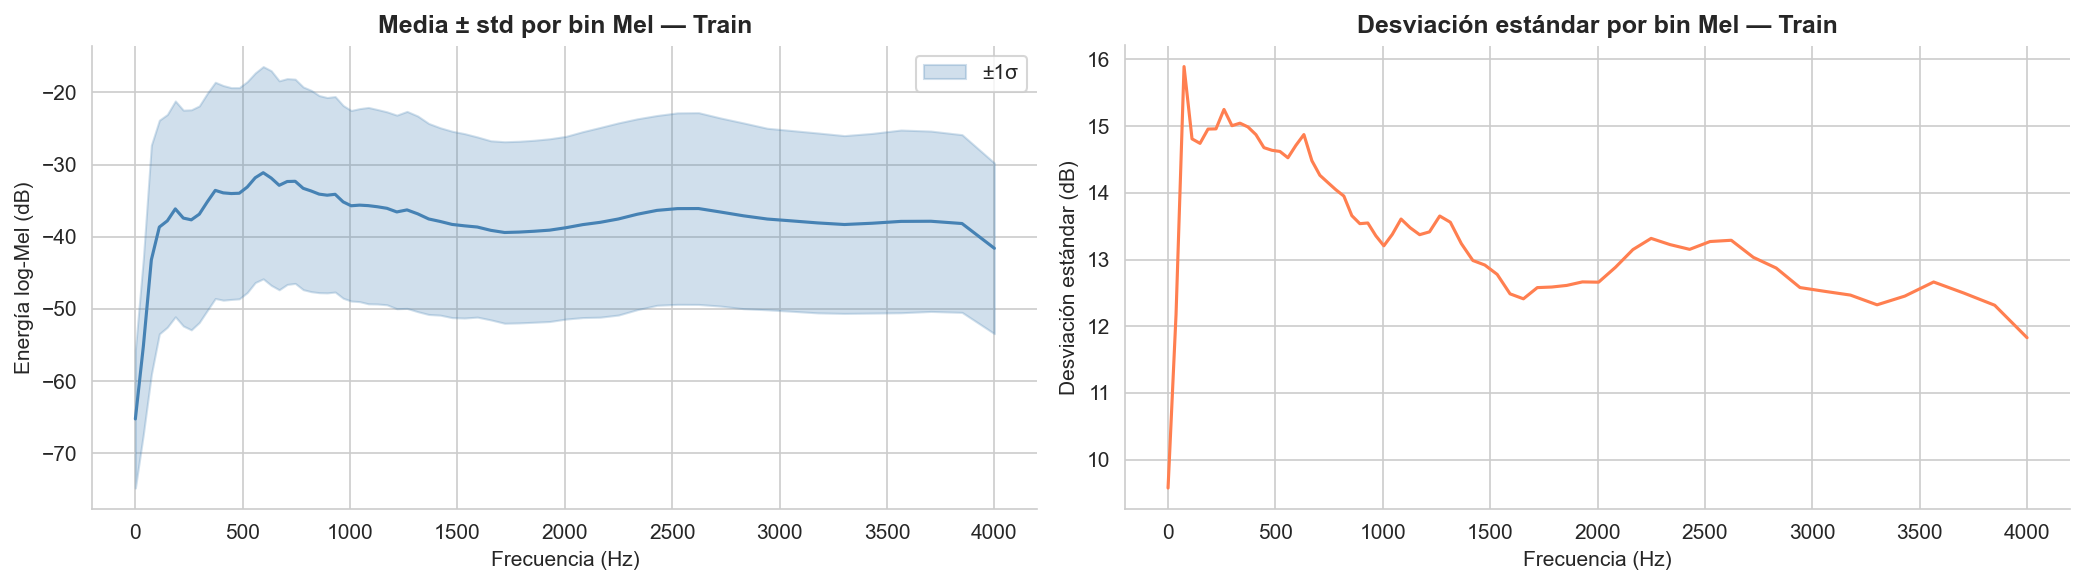

In [16]:
# VISUALIZACIÓN DE ESTADÍSTICOS POR BIN MEL
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

mel_freqs = librosa.mel_frequencies(n_mels=N_MELS, fmin=0, fmax=SR // 2)

axes[0].plot(mel_freqs, TRAIN_MEAN, color='steelblue', lw=1.5)
axes[0].fill_between(mel_freqs,
                     TRAIN_MEAN - TRAIN_STD,
                     TRAIN_MEAN + TRAIN_STD,
                     alpha=0.25, color='steelblue', label='±1σ')
axes[0].set_xlabel('Frecuencia (Hz)')
axes[0].set_ylabel('Energía log-Mel (dB)')
axes[0].set_title('Media ± std por bin Mel — Train', fontweight='bold')
axes[0].legend()
axes[0].spines[['top', 'right']].set_visible(False)

axes[1].plot(mel_freqs, TRAIN_STD, color='coral', lw=1.5)
axes[1].set_xlabel('Frecuencia (Hz)')
axes[1].set_ylabel('Desviación estándar (dB)')
axes[1].set_title('Desviación estándar por bin Mel — Train', fontweight='bold')
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUT_PATH / 'fig_normalization_stats.png', dpi=150, bbox_inches='tight')
plt.show()

#
---
#
<div style="text-align:left;">
    <span style="color:#4F75B6; font-size:25px; font-weight:bold;">BLOQUE 4. PROCESAMIENTO Y EXPORTACIÓN</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
Este bloque aplica el pipeline completo sobre los tres conjuntos y exporta los tensores resultantes a disco. El procesamiento se realiza en el orden Train → Validation → Test, garantizando que los estadísticos de normalización (calculados sobre Train en el Bloque 3) estén disponibles antes de procesar los conjuntos de evaluación. Los errores de procesamiento se registran en un log que se imprime al final de cada partición sin interrumpir el pipeline.
    </span>
</div>

In [17]:
def process_split(
    split_inventory: "pd.DataFrame",
    mean: np.ndarray,
    std: np.ndarray,
    output_path: "Path",
    split_name: str
) -> "pd.DataFrame":
    """Procesa y exporta todos los audios de una partición.

    Para cada archivo disponible en split_inventory, ejecuta el pipeline
    completo y exporta el tensor resultante a disco.

    Args:
        split_inventory: DataFrame con columnas [audio_path, subject_id, task, split, label].
        mean:            Media por bin Mel (de Train).
        std:             Std por bin Mel (de Train).
        output_path:     Directorio raíz de exportación.
        split_name:      Nombre de la partición para logging.

    Returns:
        DataFrame con log de procesamiento (una fila por archivo).
    """
    log = []

    for _, row in tqdm(split_inventory.iterrows(),
                       total=len(split_inventory),
                       desc=f"Procesando {split_name}"):
        record = {
            'subject_id': row['subject_id'],
            'task':       row['task'],
            'split':      row['split'],
            'label':      row['label'],
            'status':     None,
            'n_frames':   None,
            'duration_s': None,
            'error':      None
        }

        try:
            tensor = preprocess_audio(row['audio_path'], mean=mean, std=std)

            save_tensor(
                tensor=tensor,
                label=row['label'],
                subject_id=row['subject_id'],
                task=row['task'],
                split=row['split'],
                output_path=output_path
            )

            n_frames = tensor.shape[-1]
            record['status']    = 'OK'
            record['n_frames']  = n_frames
            record['duration_s'] = round(n_frames * HOP_LENGTH / SR, 2)

        except Exception as e:
            record['status'] = 'ERROR'
            record['error']  = str(e)

        log.append(record)

    log_df = pd.DataFrame(log)
    n_ok   = (log_df['status'] == 'OK').sum()
    n_err  = (log_df['status'] == 'ERROR').sum()
    print(f"\n{split_name}: {n_ok} OK  |  {n_err} errores")

    if n_err > 0:
        print("  Archivos con error:")
        err_df = log_df[log_df['status'] == 'ERROR'][['subject_id', 'task', 'error']]
        print(err_df.to_string(index=False))

    return log_df

<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 16. Procesamiento del conjunto Train</span>
</div>

In [18]:
# PROCESAMIENTO TRAIN
train_inv = inventory_df[(inventory_df['split'] == 'Train') & (inventory_df['exists'])]

print("=" * 70)
print("PROCESANDO TRAIN")
print("=" * 70)

log_train = process_split(
    split_inventory=train_inv,
    mean=TRAIN_MEAN,
    std=TRAIN_STD,
    output_path=OUTPUT_PATH,
    split_name='Train'
)

PROCESANDO TRAIN


Procesando Train: 100%|██████████| 856/856 [00:19<00:00, 44.49it/s]


Train: 856 OK  |  0 errores


<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 17. Procesamiento del conjunto Validation</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
Los archivos de Validation se procesan aplicando los estadísticos de normalización calculados sobre Train (<code>TRAIN_MEAN</code>, <code>TRAIN_STD</code>). No se calculan nuevos estadísticos sobre Validation. Esta es la única diferencia operativa entre el procesamiento de Train y el de los conjuntos de evaluación.
    </span>
</div>

In [19]:
# PROCESAMIENTO VALIDATION
val_inv = inventory_df[(inventory_df['split'] == 'Validation') & (inventory_df['exists'])]

print("=" * 70)
print("PROCESANDO VALIDATION")
print("=" * 70)

log_val = process_split(
    split_inventory=val_inv,
    mean=TRAIN_MEAN,
    std=TRAIN_STD,
    output_path=OUTPUT_PATH,
    split_name='Validation'
)

PROCESANDO VALIDATION


Procesando Validation: 100%|██████████| 184/184 [00:07<00:00, 24.58it/s]


Validation: 184 OK  |  0 errores


<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 18. Procesamiento del conjunto Test</span>
</div>

In [20]:
# PROCESAMIENTO TEST
test_inv = inventory_df[(inventory_df['split'] == 'Test') & (inventory_df['exists'])]

print("=" * 70)
print("PROCESANDO TEST")
print("=" * 70)

log_test = process_split(
    split_inventory=test_inv,
    mean=TRAIN_MEAN,
    std=TRAIN_STD,
    output_path=OUTPUT_PATH,
    split_name='Test'
)

PROCESANDO TEST


Procesando Test: 100%|██████████| 184/184 [00:06<00:00, 28.72it/s]


Test: 184 OK  |  0 errores


<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 19. Resumen de exportación</span>
</div>

In [21]:
# RESUMEN GLOBAL DE EXPORTACIÓN
full_log = pd.concat([log_train, log_val, log_test], ignore_index=True)

print("\n" + "=" * 70)
print("RESUMEN DE EXPORTACIÓN")
print("=" * 70)

for split_name in ['Train', 'Validation', 'Test']:
    sub   = full_log[full_log['split'] == split_name]
    n_ok  = (sub['status'] == 'OK').sum()
    n_err = (sub['status'] == 'ERROR').sum()
    print(f"  {split_name:12s}: {n_ok:4d} tensores exportados  |  {n_err} errores")

print("\nBalance ALS/HC en archivos exportados:")
ok_log = full_log[full_log['status'] == 'OK'].copy()
LABEL_MAP = {0: 'HC', 1: 'ALS'}
for split_name in ['Train', 'Validation', 'Test']:
    sub   = ok_log[ok_log['split'] == split_name]
    als_n = (sub['label'] == 1).sum()
    hc_n  = (sub['label'] == 0).sum()
    print(f"  {split_name:12s}: ALS={als_n}  HC={hc_n}")

log_path = OUTPUT_PATH / 'preprocessing_log.csv'
full_log.to_csv(log_path, index=False)
print(f"\nLog completo guardado en: {log_path}")


RESUMEN DE EXPORTACIÓN
  Train       :  856 tensores exportados  |  0 errores
  Validation  :  184 tensores exportados  |  0 errores
  Test        :  184 tensores exportados  |  0 errores

Balance ALS/HC en archivos exportados:
  Train       : ALS=568  HC=288
  Validation  : ALS=120  HC=64
  Test        : ALS=128  HC=56

Log completo guardado en: C:\Users\Laura\OneDrive\TFG\artifacts\preprocessed\preprocessing_log.csv


#
---
#
<div style="text-align:left;">
    <span style="color:#4F75B6; font-size:25px; font-weight:bold;">BLOQUE 5. CONTROL DE CALIDAD Y ANÁLISIS POST-PREPROCESAMIENTO</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
Este bloque verifica que los tensores exportados cumplen las condiciones de integridad necesarias para su uso en entrenamiento. Las verificaciones cubren cuatro dimensiones: inspección visual cualitativa de la señal y el espectrograma, validación cuantitativa de shapes y ausencia de valores no finitos, análisis de la distribución de duraciones por clase y partición, y verificación de la consistencia estadística entre particiones. Estos controles son la última línea de defensa antes de pasar al notebook de entrenamiento.
    </span>
</div>

<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 20. Inspección visual: waveform y espectrograma</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
Se visualizan la waveform original y el espectrograma log-Mel normalizado de un ejemplo representativo de cada clase (ALS y HC) para la tarea vocal "A". Esta comparación permite verificar visualmente que el preprocesamiento produce representaciones coherentes con la fisiología: las waveforms de ALS deben mostrar mayor irregularidad en amplitud y el espectrograma debe reflejar mayor inestabilidad en las bandas de F0 y formantes respecto a HC.
    </span>
</div>

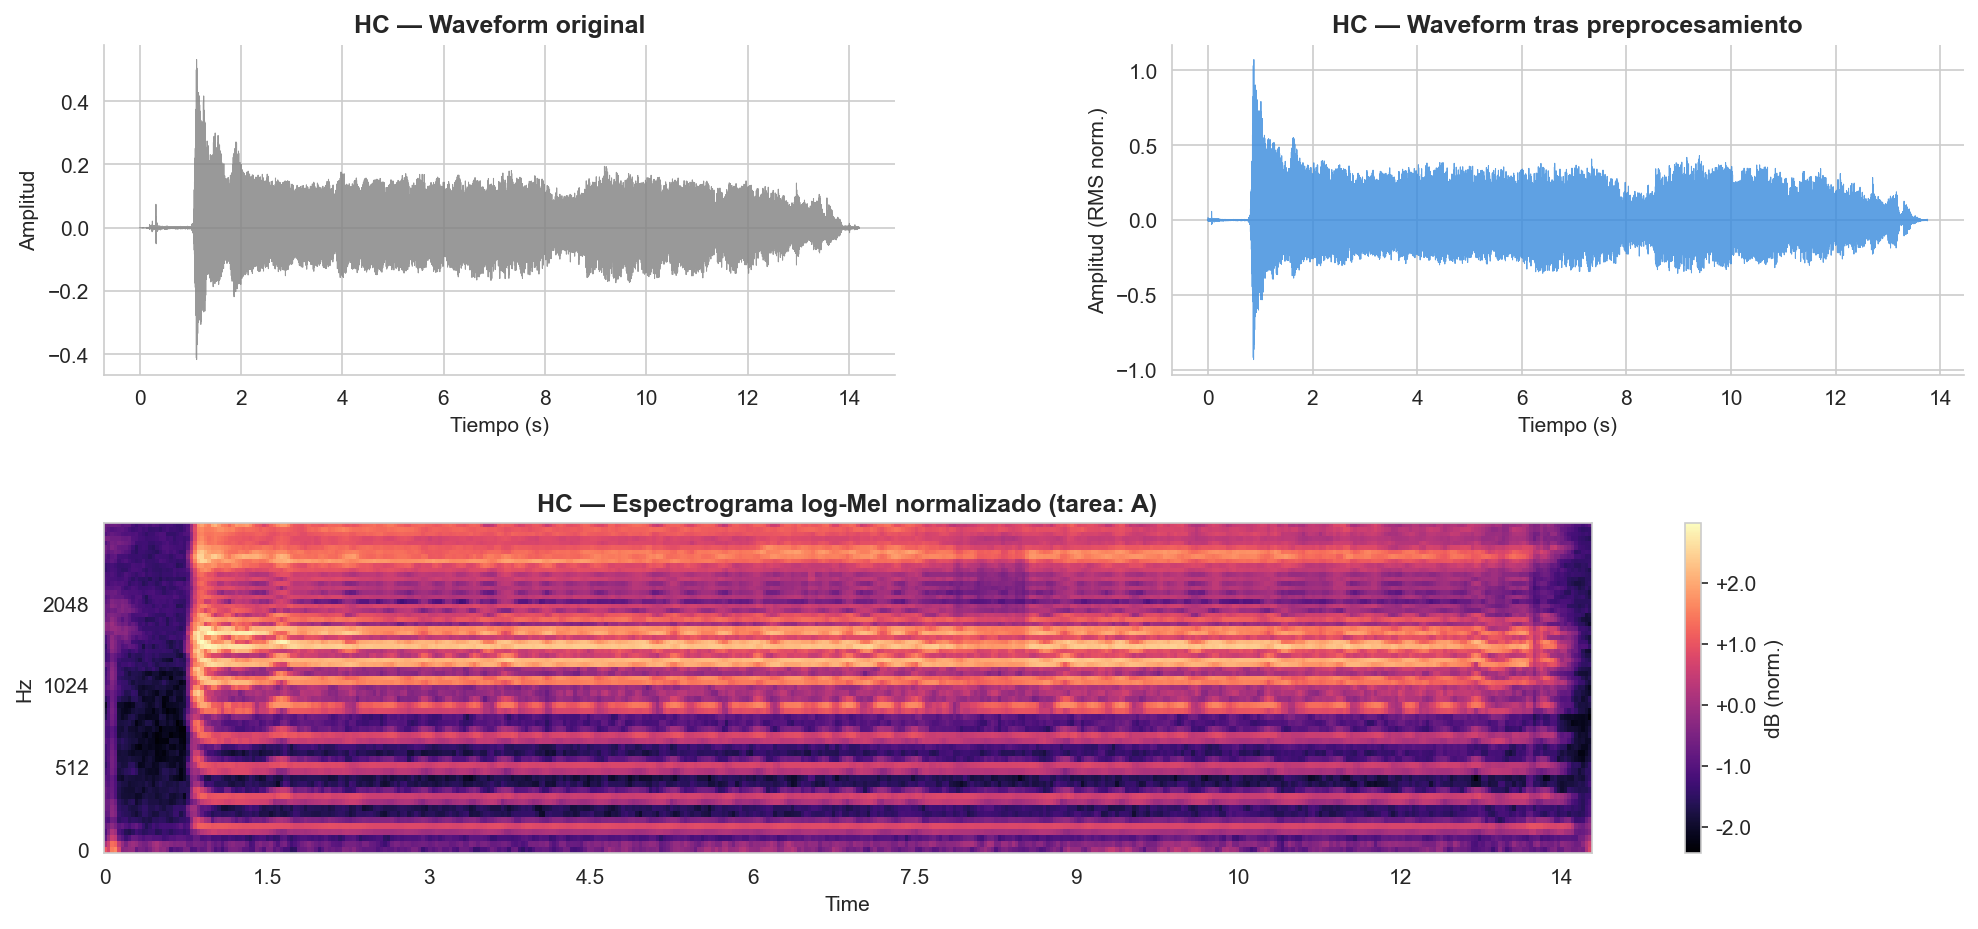

  HC: dur. original 14.20s  ->  tras trim 13.76s  |  shape: (64, 431)


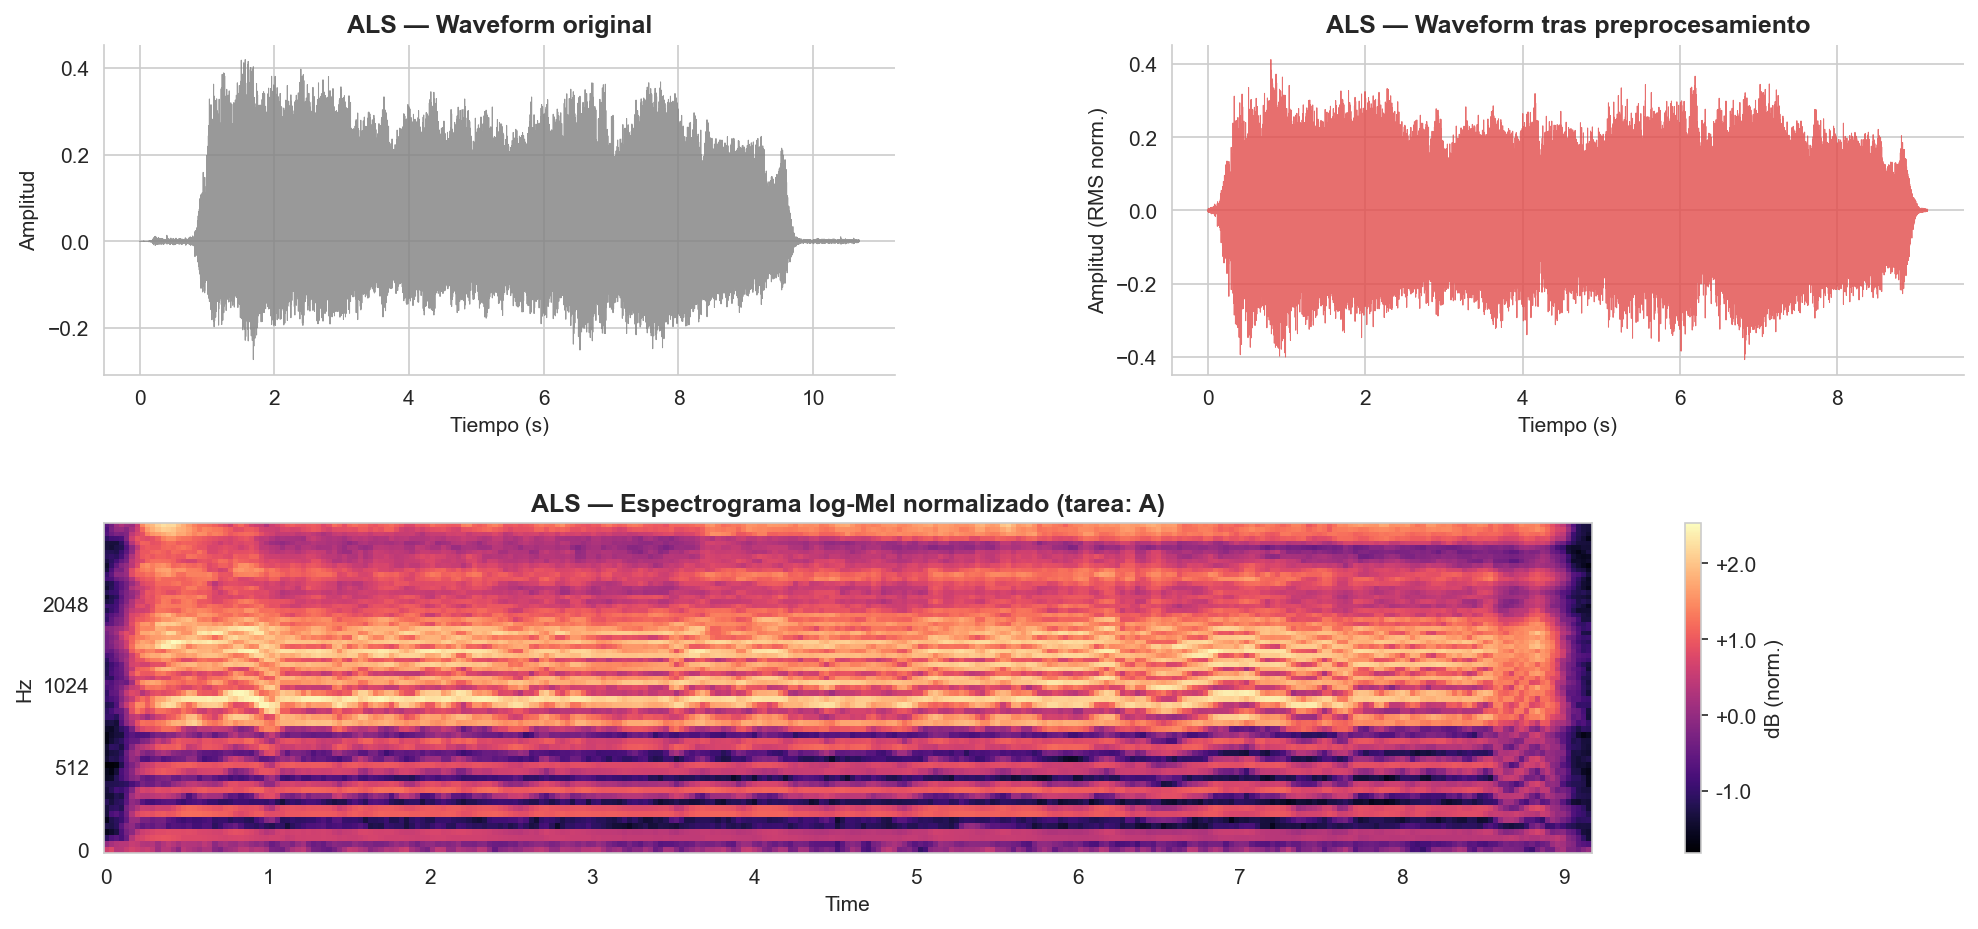

  ALS: dur. original 10.68s  ->  tras trim 9.15s  |  shape: (64, 287)


In [22]:
# INSPECCIÓN VISUAL: WAVEFORM Y ESPECTROGRAMA
task_viz = 'A'
PALETTE  = {'HC': '#378ADD', 'ALS': '#E24B4A'}

for label_str in ['HC', 'ALS']:
    example = inventory_df[
        (inventory_df['label_str'] == label_str) &
        (inventory_df['task']      == task_viz)  &
        (inventory_df['split']     == 'Train')   &
        (inventory_df['exists'])
    ].iloc[0]

    y_raw, _ = load_audio(example['audio_path'])

    y_proc   = trim_silence(y_raw)
    y_proc   = normalize_amplitude(y_proc)
    y_proc   = apply_preemphasis(y_proc)
    mel_db   = extract_mel_spectrogram(y_proc)
    mel_norm = normalize_spectrogram(mel_db, TRAIN_MEAN, TRAIN_STD)

    fig = plt.figure(figsize=(16, 7))
    gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

    # Waveform original
    ax0 = fig.add_subplot(gs[0, 0])
    t_raw = np.linspace(0, len(y_raw) / SR, len(y_raw))
    ax0.plot(t_raw, y_raw, color='gray', lw=0.5, alpha=0.8)
    ax0.set_title(f'{label_str} — Waveform original', fontweight='bold')
    ax0.set_xlabel('Tiempo (s)')
    ax0.set_ylabel('Amplitud')
    ax0.spines[['top', 'right']].set_visible(False)

    # Waveform procesada
    ax1 = fig.add_subplot(gs[0, 1])
    t_proc = np.linspace(0, len(y_proc) / SR, len(y_proc))
    ax1.plot(t_proc, y_proc, color=PALETTE[label_str], lw=0.5, alpha=0.8)
    ax1.set_title(f'{label_str} — Waveform tras preprocesamiento', fontweight='bold')
    ax1.set_xlabel('Tiempo (s)')
    ax1.set_ylabel('Amplitud (RMS norm.)')
    ax1.spines[['top', 'right']].set_visible(False)

    # Espectrograma log-Mel normalizado
    ax2 = fig.add_subplot(gs[1, :])
    librosa.display.specshow(
        mel_norm, sr=SR, hop_length=HOP_LENGTH,
        x_axis='time', y_axis='mel', ax=ax2, cmap='magma'
    )
    ax2.set_title(f'{label_str} — Espectrograma log-Mel normalizado (tarea: {task_viz})',
                  fontweight='bold')
    fig.colorbar(ax2.collections[0], ax=ax2, format='%+.1f', label='dB (norm.)')

    plt.savefig(OUTPUT_PATH / f'fig_spectrogram_{label_str}_{task_viz}.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  {label_str}: dur. original {len(y_raw)/SR:.2f}s  ->  "
          f"tras trim {len(y_proc)/SR:.2f}s  |  shape: {mel_norm.shape}")

<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 21. Validación de shapes, NaNs e Infs</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
Se carga una muestra aleatoria de tensores exportados (10 por partición) y se verifica que el shape es <code>(1, N_MELS, T)</code>, que no existen valores NaN ni Inf, y que el rango de valores es consistente con una normalización z-score (valores en torno a cero con σ ≈ 1). Un tensor con NaN propagará el error silenciosamente hasta la función de pérdida, produciendo gradientes nulos o inestabilidad durante el entrenamiento.
    </span>
</div>

In [23]:
# VALIDACIÓN DE SHAPES, NaN E Inf
print("=" * 70)
print("VALIDACIÓN DE TENSORES EXPORTADOS")
print("=" * 70)

validation_errors = []

for split_name, split_dir in [('Train', 'train'), ('Validation', 'val'), ('Test', 'test')]:
    split_path = OUTPUT_PATH / split_dir
    pt_files   = list(split_path.glob("*.pt"))

    if not pt_files:
        print(f"  {split_name}: sin archivos .pt encontrados")
        continue

    sample = np.random.choice(pt_files, size=min(10, len(pt_files)), replace=False)
    shapes, val_min, val_max = [], [], []

    for fpath in sample:
        data = torch.load(fpath, weights_only=True)
        t    = data['spectrogram']

        assert t.dim()   == 3,      f"Dim incorrecta: {t.shape}"
        assert t.shape[0] == 1,     f"Canal incorrecto: {t.shape[0]}"
        assert t.shape[1] == N_MELS, f"N_MELS incorrecto: {t.shape[1]}"

        if torch.isnan(t).any() or torch.isinf(t).any():
            validation_errors.append(f"{fpath.name}: NaN/Inf detectado")
            continue

        shapes.append(t.shape[2])
        val_min.append(t.min().item())
        val_max.append(t.max().item())

    print(f"\n  {split_name} ({len(pt_files)} archivos, muestra={len(sample)}):")
    if shapes:
        print(f"    Shape:   (1, {N_MELS}, T)  |  T en [{min(shapes)}, {max(shapes)}] frames")
        print(f"    Rango:   [{min(val_min):.3f}, {max(val_max):.3f}]")
    print(f"    NaN/Inf: {'✓ ninguno detectado' if not validation_errors else ' detectados'}")

if not validation_errors:
    print("\n✓  Todos los tensores superaron la validación de integridad")
else:
    for err in validation_errors:
        print(f"{err}")

VALIDACIÓN DE TENSORES EXPORTADOS

  Train (856 archivos, muestra=10):
    Shape:   (1, 64, T)  |  T en [204, 807] frames
    Rango:   [-3.357, 5.628]
    NaN/Inf: ✓ ninguno detectado

  Validation (184 archivos, muestra=10):
    Shape:   (1, 64, T)  |  T en [129, 703] frames
    Rango:   [-3.380, 4.923]
    NaN/Inf: ✓ ninguno detectado

  Test (184 archivos, muestra=10):
    Shape:   (1, 64, T)  |  T en [51, 879] frames
    Rango:   [-3.387, 4.240]
    NaN/Inf: ✓ ninguno detectado

✓  Todos los tensores superaron la validación de integridad


<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 22. Distribución de duraciones por split y clase</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
El análisis de duraciones responde a dos preguntas de calidad. La primera es técnica: la variabilidad en la longitud temporal de los espectrogramas debe conocerse antes de diseñar la estrategia de padding/cropping en el DataLoader del notebook de entrenamiento. La segunda es clínica: si las grabaciones de ALS son sistemáticamente más cortas que las de HC, podría existir un sesgo de longitud como señal espuria de clasificación.
    </span>
</div>

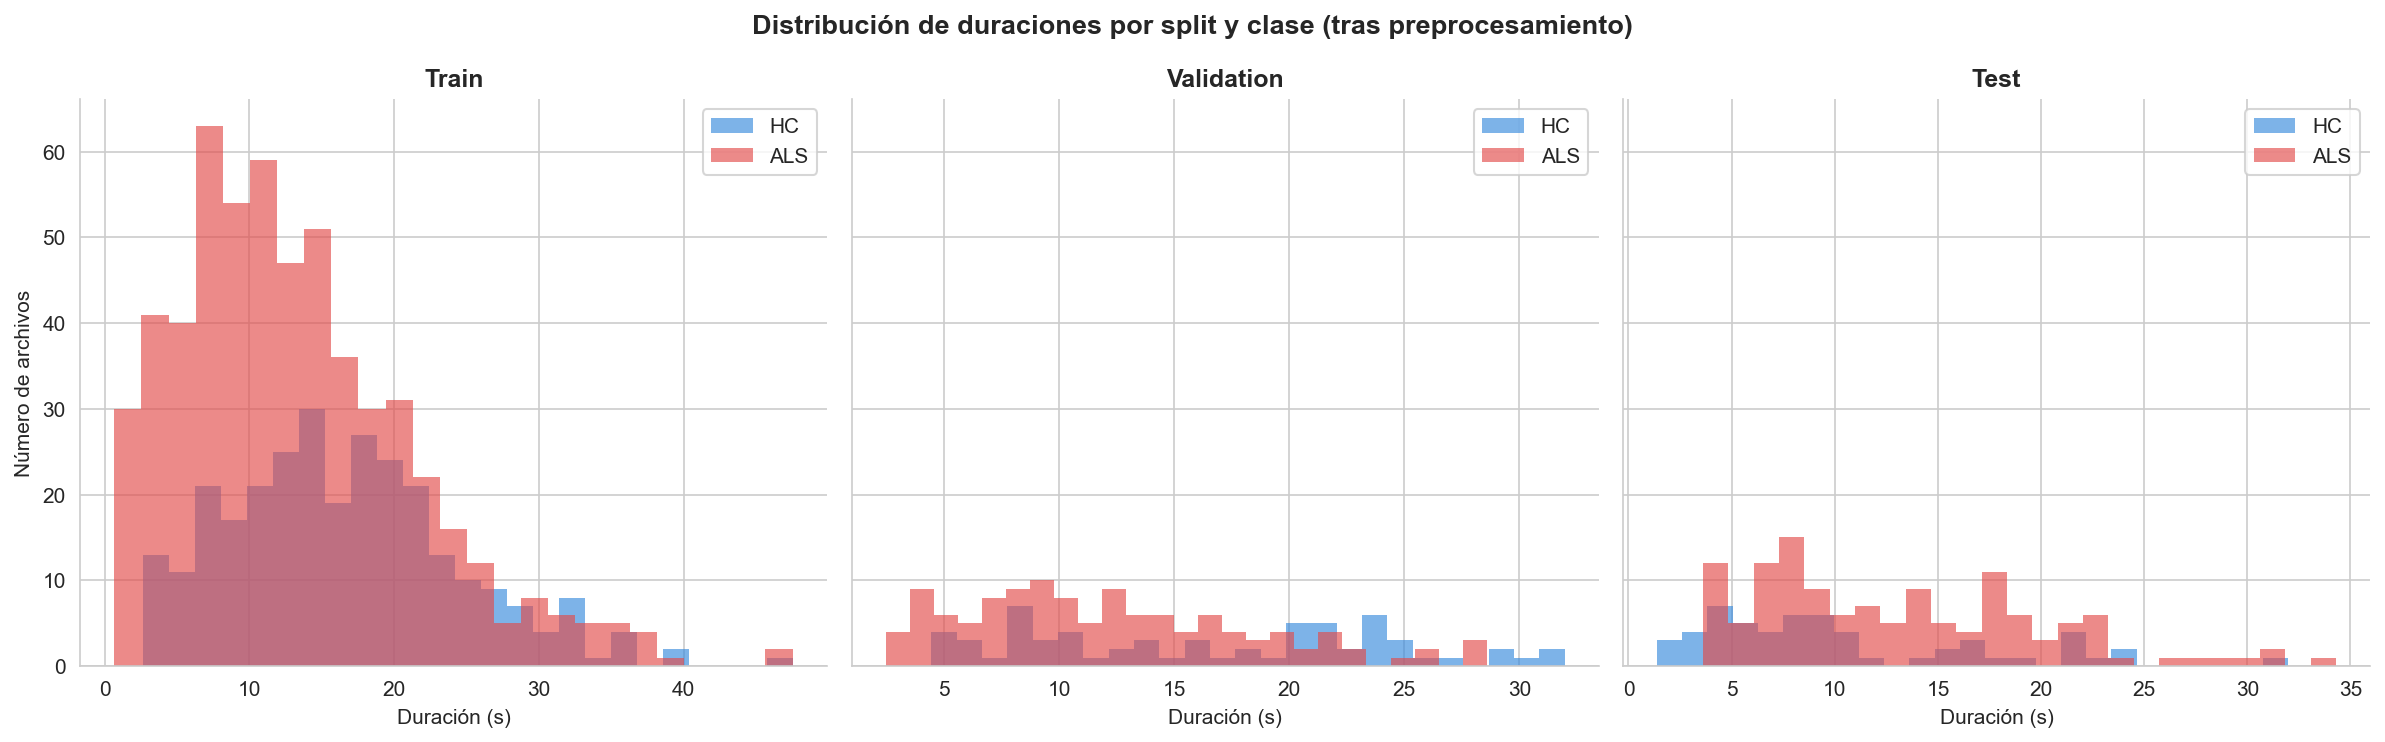

Estadísticos de duración (segundos):

  Train:
    HC : n= 288  mean=16.55s  std=8.02s  min=2.66s  max=47.58s
    ALS: n= 568  mean=13.19s  std=8.12s  min=0.67s  max=47.52s

  Validation:
    HC : n=  64  mean=16.52s  std=7.73s  min=4.45s  max=31.97s
    ALS: n= 120  mean=12.11s  std=6.20s  min=2.46s  max=28.58s

  Test:
    HC : n=  56  mean=10.35s  std=6.92s  min=1.38s  max=31.97s
    ALS: n= 128  mean=13.13s  std=6.91s  min=3.62s  max=34.30s


In [24]:
# DISTRIBUCIÓN DE DURACIONES
ok_log = full_log[full_log['status'] == 'OK'].copy()

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
LABEL_MAP = {0: 'HC', 1: 'ALS'}
C_PALETTE = {0: '#378ADD', 1: '#E24B4A'}

for ax, split_name in zip(axes, ['Train', 'Validation', 'Test']):
    sub = ok_log[ok_log['split'] == split_name]
    for lbl in [0, 1]:
        data = sub[sub['label'] == lbl]['duration_s'].dropna()
        if len(data):
            ax.hist(data, bins=25, alpha=0.65,
                    color=C_PALETTE[lbl], label=LABEL_MAP[lbl], edgecolor='none')
    ax.set_title(split_name, fontweight='bold')
    ax.set_xlabel('Duración (s)')
    ax.legend()
    ax.spines[['top', 'right']].set_visible(False)

axes[0].set_ylabel('Número de archivos')
fig.suptitle('Distribución de duraciones por split y clase (tras preprocesamiento)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_PATH / 'fig_duration_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Estadísticos resumen
print("Estadísticos de duración (segundos):")
for split_name in ['Train', 'Validation', 'Test']:
    sub = ok_log[ok_log['split'] == split_name]
    print(f"\n  {split_name}:")
    for lbl in [0, 1]:
        d = sub[sub['label'] == lbl]['duration_s'].dropna()
        if len(d):
            print(f"    {LABEL_MAP[lbl]:3s}: n={len(d):4d}  "
                  f"mean={d.mean():.2f}s  std={d.std():.2f}s  "
                  f"min={d.min():.2f}s  max={d.max():.2f}s")

<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 23. Consistencia entre particiones</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
Se verifica que no existe solapamiento de sujetos en los tensores exportados (consistente con el split original), que la distribución de tareas es homogénea entre particiones, y que los tensores de Validation y Test tienen distribuciones de valores estadísticamente consistentes con los de Train tras la normalización. Una distribución marcadamente distinta indicaría diferencias en las condiciones de grabación no detectadas en el Notebook 1.
    </span>
</div>

In [25]:
# CONSISTENCIA ENTRE PARTICIONES
print("=" * 70)
print("VERIFICACIÓN DE CONSISTENCIA ENTRE PARTICIONES")
print("=" * 70)

# 1. No solapamiento de sujetos en tensores exportados
train_exp = set(full_log[(full_log['split'] == 'Train')      & (full_log['status'] == 'OK')]['subject_id'])
val_exp   = set(full_log[(full_log['split'] == 'Validation') & (full_log['status'] == 'OK')]['subject_id'])
test_exp  = set(full_log[(full_log['split'] == 'Test')       & (full_log['status'] == 'OK')]['subject_id'])

assert len(train_exp & val_exp)  == 0
assert len(train_exp & test_exp) == 0
assert len(val_exp   & test_exp) == 0
print("✓  No solapamiento de sujetos entre particiones exportadas")

# 2. Distribución de tareas por split
print("\nDistribución de tareas por partición (archivos OK):")
task_dist = ok_log.groupby(['split', 'task']).size().unstack(fill_value=0)
print(task_dist.to_string())

# 3. Distribución de valores en los espectrogramas (muestra de 5 tensores/split)
print("\nEstadísticos de valores de espectrograma (muestra 5 tensores/split):")
for split_name, split_dir in [('Train', 'train'), ('Validation', 'val'), ('Test', 'test')]:
    pt_files = list((OUTPUT_PATH / split_dir).glob("*.pt"))
    if not pt_files:
        continue
    sample = np.random.choice(pt_files, size=min(5, len(pt_files)), replace=False)
    vals   = torch.cat([
        torch.load(f, weights_only=True)['spectrogram'].flatten() for f in sample
    ])
    print(f"  {split_name:12s}: mean={vals.mean():.4f}  std={vals.std():.4f}  "
          f"min={vals.min():.3f}  max={vals.max():.3f}")
print("\nEsperado tras z-score: mean≈0, std≈1")

VERIFICACIÓN DE CONSISTENCIA ENTRE PARTICIONES
✓  No solapamiento de sujetos entre particiones exportadas

Distribución de tareas por partición (archivos OK):
task          A    E    I   KA    O   PA   TA    U
split                                             
Test         23   23   23   23   23   23   23   23
Train       107  107  107  107  107  107  107  107
Validation   23   23   23   23   23   23   23   23

Estadísticos de valores de espectrograma (muestra 5 tensores/split):
  Train       : mean=-0.0130  std=1.0301  min=-3.387  max=3.106
  Validation  : mean=-0.1157  std=1.0741  min=-2.971  max=3.508
  Test        : mean=-0.2077  std=1.0898  min=-2.976  max=2.895

Esperado tras z-score: mean≈0, std≈1


#
---
#
<div style="text-align:left;">
    <span style="color:#4F75B6; font-size:25px; font-weight:bold;">BLOQUE 6. GUARDADO DE CONFIGURACIÓN</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
La reproducibilidad total del pipeline requiere guardar no solo los tensores procesados, sino también la configuración completa que los generó. El archivo <code>config.json</code> actúa como el registro de laboratorio del preprocesamiento: cualquier experimento posterior que requiera aplicar el mismo preprocesamiento a nuevos datos (por ejemplo, datos de validación externa o de una cohorte clínica diferente) debe leer este archivo para reproducir exactamente las mismas transformaciones con los mismos parámetros y los mismos estadísticos de normalización.
<br><br>
Los estadísticos de normalización (<code>TRAIN_MEAN</code> y <code>TRAIN_STD</code>) se guardan como listas Python en el JSON para que puedan cargarse sin dependencia de archivos NumPy binarios.
    </span>
</div>

<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 24. Exportación de config.json</span>
</div>

In [26]:
# GUARDADO DE CONFIGURACIÓN
config = {
    # Metadatos
    "notebook":         "03_preprocessing_mel_spectrogram",
    "version":          "1.0",
    "date":             datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "seed":             SEED,

    # Rutas
    "audio_path":       str(AUDIO_PATH),
    "split_path":       str(SPLIT_PATH),
    "output_path":      str(OUTPUT_PATH),

    # Parámetros de audio
    "sample_rate":      SR,
    "trim_top_db":      TRIM_TOP_DB,
    "preemphasis_coef": PREEMPH_COEF,
    "rms_target":       0.1,

    # Parámetros del espectrograma
    "n_fft":            N_FFT,
    "hop_length":       HOP_LENGTH,
    "n_mels":           N_MELS,
    "frame_duration_ms": round(HOP_LENGTH / SR * 1000, 2),

    # Estadísticos de normalización (estimados SOLO sobre Train)
    "normalization": {
        "strategy":       "z-score por bin Mel, stats estimados sobre Train",
        "train_mean":     TRAIN_MEAN.tolist(),
        "train_std":      TRAIN_STD.tolist(),
        "n_frames_train": int(n_frames_total)
    },

    # Resumen de procesamiento
    "processing_summary": {
        "train": {
            "total":  int((full_log['split'] == 'Train').sum()),
            "ok":     int(((full_log['split'] == 'Train')      & (full_log['status'] == 'OK')).sum()),
            "errors": int(((full_log['split'] == 'Train')      & (full_log['status'] == 'ERROR')).sum())
        },
        "val": {
            "total":  int((full_log['split'] == 'Validation').sum()),
            "ok":     int(((full_log['split'] == 'Validation') & (full_log['status'] == 'OK')).sum()),
            "errors": int(((full_log['split'] == 'Validation') & (full_log['status'] == 'ERROR')).sum())
        },
        "test": {
            "total":  int((full_log['split'] == 'Test').sum()),
            "ok":     int(((full_log['split'] == 'Test')       & (full_log['status'] == 'OK')).sum()),
            "errors": int(((full_log['split'] == 'Test')       & (full_log['status'] == 'ERROR')).sum())
        }
    },

    # Formato del tensor exportado
    "tensor_format": {
        "shape":            "(1, n_mels, T)  — (canal, bins_Mel, frames_temporales)",
        "dtype":            "torch.float32",
        "keys":             ["spectrogram", "label", "subject_id"],
        "labels":           {"HC": 0, "ALS": 1},
        "filename_pattern": "{subjectID}_{task}.pt"
    }
}

with open(CONFIG_PATH, 'w', encoding='utf-8') as f:
    json.dump(config, f, indent=2, ensure_ascii=False)

print(f"Configuración guardada en: {CONFIG_PATH}")
print()

# Verificación de lectura
with open(CONFIG_PATH) as f:
    config_loaded = json.load(f)

print("Verificación — parámetros guardados:")
for key in ["version", "date", "sample_rate", "n_fft", "hop_length",
            "n_mels", "trim_top_db", "preemphasis_coef"]:
    print(f"  {key:22s}: {config_loaded[key]}")
print(f"  {'train_mean (n_bins)':22s}: {len(config_loaded['normalization']['train_mean'])}")
print(f"  {'train_std  (n_bins)':22s}: {len(config_loaded['normalization']['train_std'])}")

Configuración guardada en: C:\Users\Laura\OneDrive\TFG\artifacts\preprocessed\config.json

Verificación — parámetros guardados:
  version               : 1.0
  date                  : 2026-04-09 22:49:17
  sample_rate           : 8000
  n_fft                 : 1024
  hop_length            : 256
  n_mels                : 64
  trim_top_db           : 30
  preemphasis_coef      : 0.97
  train_mean (n_bins)   : 64
  train_std  (n_bins)   : 64


#
---
#
<div style="text-align:left;">
    <span style="color:#4F75B6; font-size:25px; font-weight:bold;">CONCLUSIONES</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
Este notebook ha completado el <b>HITO 2</b> del proyecto, construyendo el pipeline de preprocesamiento que transforma las grabaciones crudas del dataset VOC-ALS en tensores PyTorch normalizados y listos para entrenamiento. A continuación se sintetizan los resultados y las decisiones metodológicas relevantes para los notebooks de modelado.
    </span>
</div>

<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 25. Conclusiones del notebook</span>
</div>

<div style="text-align:left;"> 
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;"> 
Este notebook ha implementado y ejecutado el pipeline completo de preprocesamiento de la señal de voz que alimenta al modelo profundo del Notebook 04. Los 1.224 audios del dataset VOC-ALS se han transformado en tensores log-Mel normalizados, listos para ser consumidos por la red BiLSTM, y se han exportado junto con los estadísticos de normalización y el fichero <code>config.json</code> que documenta de forma reproducible todos los parámetros del pipeline. Las conclusiones operativas del notebook son las siguientes:
<br>
<ul>
<li><b>Sample rate ajustado al valor nativo del dataset.</b> Tras descartar la incorporación de encoders preentrenados (Wav2Vec 2.0, HuBERT) por razones metodológicas relacionadas con la comparabilidad arquitectónica frente al baseline clásico, el <code>SR</code> objetivo se ha fijado en <b>8.000 Hz</b>, coincidente con el sample rate de adquisición de la totalidad de los archivos del dataset VOC-ALS verificado en el Notebook 1. La carga con <code>librosa.load(sr=8000)</code> es por tanto una operación identidad sobre los audios originales, sin upsampling implícito. Esta decisión elimina las bandas Mel inertes que aparecían en versiones previas del pipeline correspondientes a frecuencias por encima del límite de Nyquist del audio original (4 kHz), y rehabilita la interpretación física de cualquier análisis de saliency posterior por banda de frecuencia.</li><br>

<li><b>Parámetros del pipeline coherentes con el nuevo sample rate.</b> El conjunto de hiperparámetros se ha redimensionado para mantener la misma resolución temporal y frecuencial efectiva que la versión anterior, ajustando las cifras al nuevo sample rate: <code>n_fft = 1024</code> (resolución frecuencial de 7.8 Hz/bin, idéntica a la previa), <code>hop_length = 256</code> (resolución temporal de 32 ms/frame, idéntica a la previa) y <code>n_mels = 64</code> (adecuado para cubrir el rango [0, 4000] Hz sin redundancia, frente a las 128 bandas previas que incluían bandas inertes). El resto de parámetros del pipeline auxiliar se mantienen sin cambios: <code>trim_top_db = 30</code> dB para la eliminación de silencios sin afectar a las pausas clínicas, <code>preemphasis_coef = 0.97</code> como estándar en análisis vocal patológico, normalización z-score banda a banda con estadísticos calculados exclusivamente sobre Train.</li><br>

<li><b>Estadísticos de normalización calculados de forma honesta.</b> Los estadísticos de normalización (media y desviación estándar por bin Mel) se han calculado sobre <b>383.107 frames</b> procedentes exclusivamente de los 856 archivos del conjunto de Train, sin participación alguna de los datos de validation o test. Los valores resultantes se concentran en rangos físicamente coherentes: la media por banda oscila entre -65.254 y -31.127 dB (valor medio -37.213 dB) y la desviación estándar entre 9.575 y 15.893 dB (valor medio 13.480 dB). Estos vectores quedan registrados en el <code>config.json</code> y son los únicos que deben aplicarse sobre validation y test, garantizando que ninguna información de los conjuntos de evaluación filtra al proceso de normalización.</li><br>

<li><b>Exportación completa y verificación de integridad.</b> Los tres splits se han procesado sin errores: 856 tensores de Train, 184 de Validation y 184 de Test, manteniendo el balance ALS/HC esperado en cada partición (Train ALS=568 / HC=288; Validation ALS=120 / HC=64; Test ALS=128 / HC=56). La inspección de una muestra aleatoria de 10 tensores por split confirma que todos cumplen el shape esperado <code>(1, 64, T)</code>, que la longitud temporal T se encuentra en rangos coherentes con las duraciones originales de los audios (Train: T ∈ [204, 807]; Validation: T ∈ [129, 703]; Test: T ∈ [51, 879]) y que ningún tensor contiene valores NaN o Inf. La distribución de tareas vocales por partición es perfectamente uniforme: 8 tareas × N sujetos en cada split.</li><br>

<li><b>Verificación post-normalización.</b> El cálculo de los estadísticos descriptivos sobre una muestra de 5 tensores por split confirma que la normalización z-score se ha aplicado correctamente: la media empírica está en torno a cero (Train: -0.0130; Validation: -0.1157; Test: -0.2077) y la desviación estándar próxima a uno (Train: 1.0301; Validation: 1.0741; Test: 1.0898). Las pequeñas desviaciones observadas en validation y test son las esperadas y reflejan el ligero shift entre los estadísticos del Train (con los que se normalizan los tres splits) y los estadísticos reales de las particiones de evaluación; este shift es metodológicamente correcto y constituye precisamente la razón por la que los estadísticos no deben recalcularse sobre validation o test.</li><br>

<li><b>Distribución de duraciones por split y clase.</b> Las duraciones medias de los audios procesados se sitúan entre 10.35 y 16.55 segundos, con desviaciones estándar de 6 a 8 segundos y rangos máximos de hasta 47.58 segundos. La distribución es ligeramente heterogénea entre clases: en Train y Validation, los sujetos HC presentan duraciones medias mayores que los sujetos ALS (Train: HC 16.55s vs ALS 13.19s; Validation: HC 16.52s vs ALS 12.11s), patrón coherente con la mayor dificultad articulatoria de los pacientes para sostener las tareas vocales largas. En Test, sin embargo, la relación se invierte (HC 10.35s vs ALS 13.13s), lo cual es consecuencia del pequeño tamaño del conjunto de Test (7 sujetos HC, 16 ALS) y de la varianza esperable a esta escala. Esta heterogeneidad debe tenerse presente en el Notebook 04 al definir la estrategia de padding o truncamiento.</li><br>

<li><b>Trazabilidad y reproducibilidad.</b> El fichero <code>config.json</code> exportado al final del notebook documenta de forma íntegra todos los parámetros del pipeline (sample rate, n_fft, hop_length, n_mels, trim_top_db, coeficiente de preénfasis y vectores completos de media y desviación estándar por bin Mel), junto con la versión y la fecha de generación. Cualquier ejecución posterior del Notebook 04 lee estos parámetros directamente desde el config, sin riesgo de inconsistencia entre la fase de preprocesamiento y la fase de modelado. Adicionalmente, se ha exportado un <code>preprocessing_log.csv</code> con el detalle por archivo del procesado.</li>
    </span> 
</div>

<div style='background-color:#D4EDDA; padding:20px; border-left:5px solid #DEE2E6; margin-top:20px; color:black;'>
    <span style='font-size:16px; font-family:Calibri;'>
<b>NOTEBOOK COMPLETADO</b>
<br><br>
El pipeline de preprocesamiento ha sido ejecutado y los tensores están disponibles en <b>artifacts/preprocessed/</b>.
<br><br>
<b>Siguiente paso:</b>
<br><br>
<code style='background-color:#F8F9FA; padding:5px; border:1px solid #DEE2E6; color:black;'>
04_model_deep_learning_v1_0.ipynb
</code>
<br><br>
<b>Resumen de lo realizado en este notebook:</b>
<ul>
<li><b>artifacts/preprocessed/train/*.pt</b>     — Tensores de entrenamiento.</li>
<li><b>artifacts/preprocessed/val/*.pt</b>     — Tensores de validación.</li>
<li><b>artifacts/preprocessed/test/*.pt</b>     — Tensores de test.</li>
<li><b>artifacts/preprocessed/config.json</b>     — Configuración completa del pipeline.</li>
<li><b>artifacts/preprocessed/preprocessing_log.csv</b>     — Log de procesamiento por archivo.</li>
<li><b>artifacts/preprocessed/fig_normalization_stats.png</b>     — Estadísticos de normalización.</li>
<li><b>artifacts/preprocessed/fig_spectrogram_ALS_A.png</b> — Espectrograma ejemplo ALS.</li>
<li><b>artifacts/preprocessed/fig_spectrogram_HC_A.png</b>     — Espectrograma ejemplo HC.</li>
<li><b>artifacts/preprocessed/fig_duration_distribution.png</b> — Distribución de duraciones.</li>
</ul>
    </span>
</div>